# 06 · Round trajectories, striking and grappling

Research question: how do finish risk and activity change within fights? The round table supports detailed strike targets, positions, takedowns and control. Missing time is not zero control.

In [1]:
from pathlib import Path
import sys
import io
import pandas as pd
import numpy as np
from IPython.display import display, Image
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'data' / 'raw').exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.data_loader import load_raw, profile_sources, verify_raw, TABLES
from src.pipeline import prepare
from src.analysis import *
from src.visualization import *
def show(figure):
    buffer = io.BytesIO()
    figure.savefig(buffer, format='png', bbox_inches='tight')
    display(Image(data=buffer.getvalue()))
    plt.close(figure)

## Prepare cohort

Round statistics are linked by fight ID and validated against corner identities.

In [2]:
data = prepare(save=False)
fights, appearances = cohort(data)
print(f"Cohort: {len(fights):,} fights, {fights.event_id.nunique():,} events, {appearances.fighter_id.nunique():,} fighters")
print(f"Date range: {fights.event_date.min():%Y-%m-%d} to {fights.event_date.max():%Y-%m-%d}")

Cohort: 8,820 fights, 783 events, 2,735 fighters
Date range: 1994-03-11 to 2026-08-08


## Risk sets

The denominator is fights reaching each round, separately by schedule. Late-round fighters are a selected subset.

,scheduled_rounds,round_no,at_risk,finishes,finish_risk
0,3,1,7777,2088,0.268484
1,3,2,5643,1254,0.222222
2,3,3,4361,591,0.135519
3,5,1,785,175,0.222930
4,5,2,607,128,0.210873
5,5,3,477,85,0.178197
6,5,4,390,50,0.128205
7,5,5,339,35,0.103245


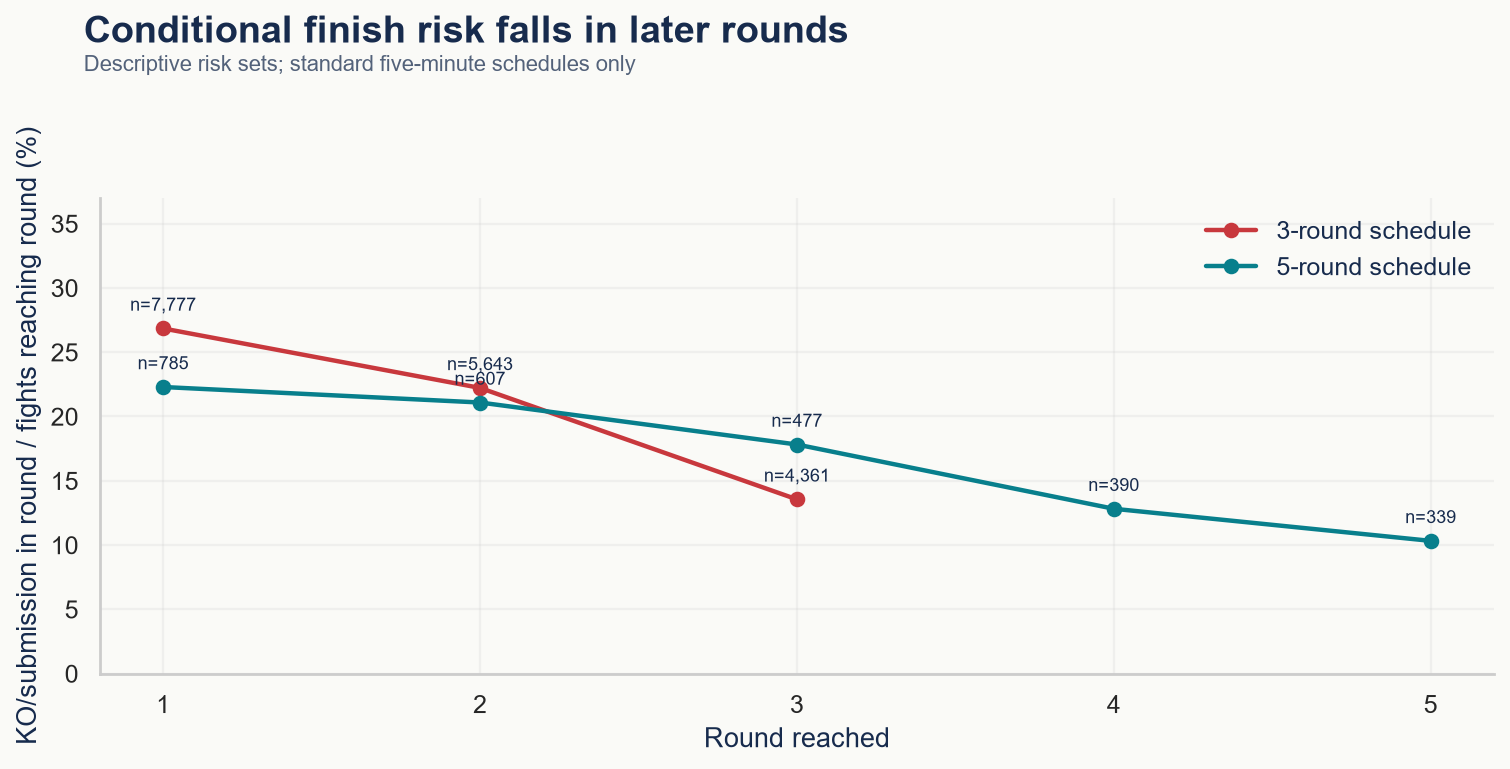

In [3]:
display(round_hazard(fights))
show(hazard_chart(fights))

## Activity and coverage

Only observed rounds with positive elapsed time contribute exposure. Fight-level totals require complete round sequences.

In [4]:
rounds = data['rounds'][data['rounds'].in_scope].copy()
tables = export_performance(data)
display(tables['round_activity'])
display(rounds[['round_no','sig_landed','sig_atmp','td_success','td_atmp','ctrl_seconds','round_duration_seconds']].describe())

,round_no,fighter_rounds,observed_seconds,sig_landed_per_minute,td_per_15
0,1,17598,4648274.0,3.261598,1.522630
1,2,12648,3408890.0,3.618157,1.463702
2,3,9736,2726072.0,3.670094,1.548382
3,4,780,221848.0,3.819913,1.168368
4,5,678,194360.0,3.882280,1.324347


,round_no,sig_landed,sig_atmp,td_success,td_atmp,ctrl_seconds,round_duration_seconds
count,41440.000000,41440.000000,41440.000000,41440.000000,41440.000000,41008.000000,41440.000000
mean,1.897008,15.726207,35.062838,0.450579,1.202461,55.874342,270.256853
std,0.933572,12.023236,24.614950,0.796824,1.614919,73.841972,76.899573
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000
25%,1.000000,7.000000,16.000000,0.000000,0.000000,0.000000,300.000000
50%,2.000000,13.000000,31.000000,0.000000,1.000000,20.000000,300.000000
75%,3.000000,22.000000,49.000000,1.000000,2.000000,89.000000,300.000000
max,5.000000,141.000000,220.000000,9.000000,14.000000,300.000000,1860.000000


## Striking and grappling through time

Rates pool landed actions and exposure. Comparing early and later years requires coverage awareness.

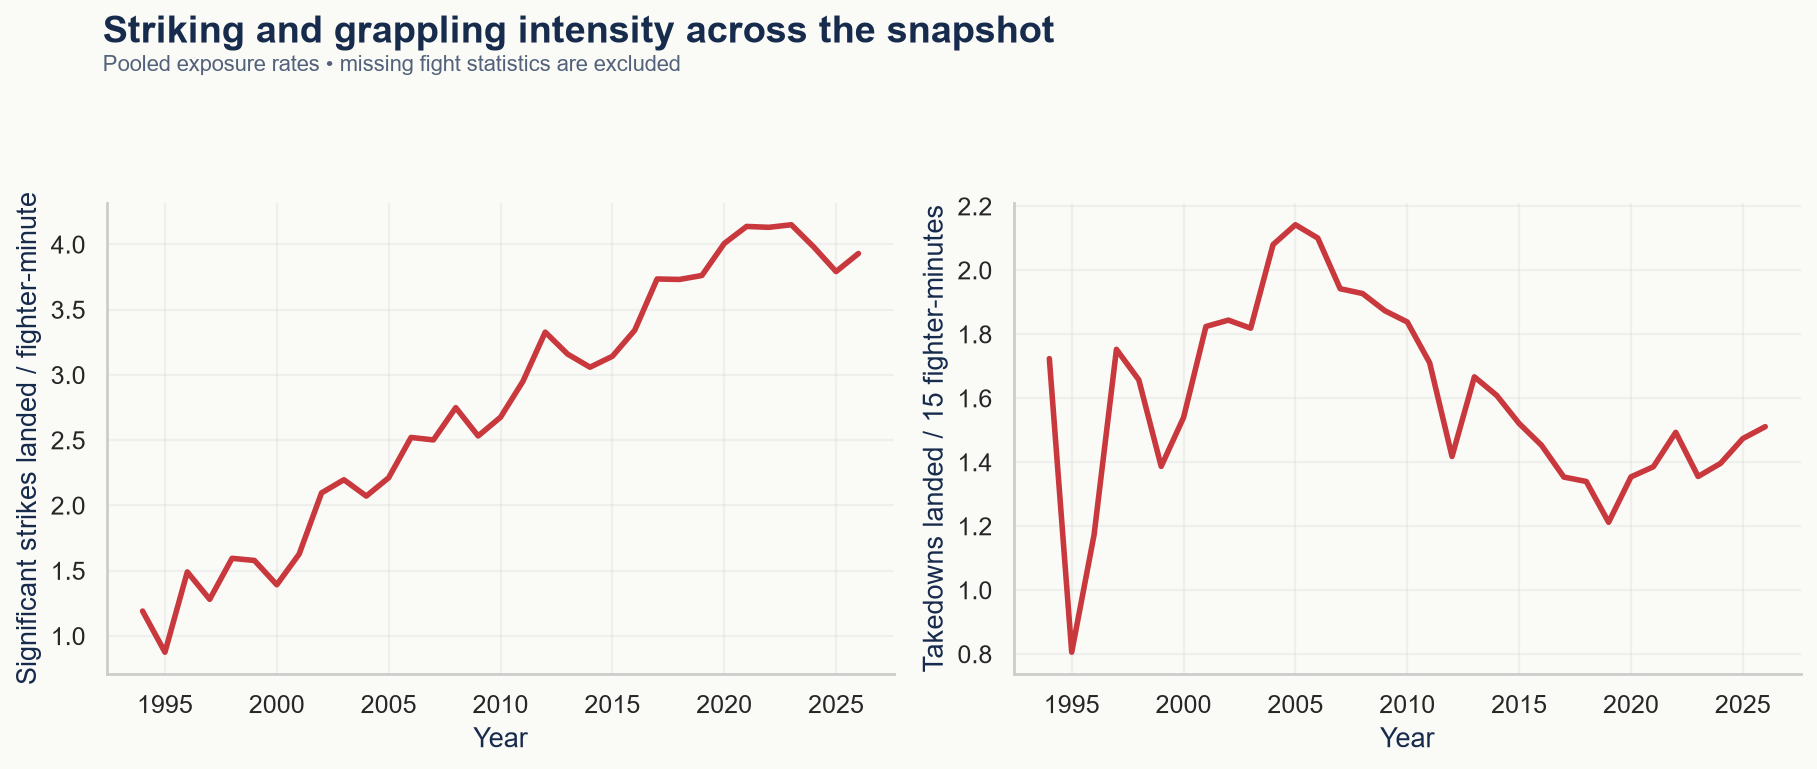

,fight_year,appearances,observed_appearances,coverage,sig_landed_per_minute,sig_accuracy,td_per_15,td_accuracy,knockdowns_per_15,sub_attempts_per_15,head_share,body_share,leg_share,distance_share,clinch_share,ground_share
21,2015,946,946,1.0,3.142498,0.434608,1.520804,0.347634,0.280030,0.448347,0.640302,0.202964,0.156734,0.689629,0.167320,0.143051
22,2016,986,986,1.0,3.342282,0.431343,1.452750,0.379914,0.303397,0.419562,0.645131,0.196652,0.158216,0.715380,0.142378,0.142242
23,2017,914,914,1.0,3.734802,0.430900,1.353276,0.369043,0.330104,0.437649,0.645203,0.193676,0.161121,0.733883,0.133419,0.132699
24,2018,948,948,1.0,3.731403,0.438302,1.339588,0.361497,0.305946,0.440334,0.639080,0.202273,0.158646,0.738953,0.126411,0.134636
25,2019,1032,1032,1.0,3.761547,0.438529,1.211936,0.355606,0.284329,0.337078,0.624749,0.205787,0.169464,0.767147,0.123313,0.109540
26,2020,912,912,1.0,4.006715,0.474589,1.353890,0.369841,0.279754,0.420379,0.619455,0.212874,0.167671,0.789366,0.105765,0.104869
27,2021,1018,1018,1.0,4.137492,0.472576,1.385570,0.367045,0.264908,0.394764,0.627351,0.216392,0.156257,0.814052,0.094428,0.091520
28,2022,1022,1022,1.0,4.130702,0.474070,1.493171,0.379464,0.344578,0.416196,0.625782,0.217827,0.156391,0.802216,0.098620,0.099165
29,2023,1040,1040,1.0,4.150478,0.480030,1.355209,0.356294,0.281947,0.408292,0.602751,0.222229,0.175019,0.794134,0.111211,0.094655
30,2024,1034,1034,1.0,3.980440,0.472135,1.395998,0.365688,0.228973,0.365618,0.623884,0.214635,0.161481,0.821591,0.086431,0.091977


,weight_class,appearances,observed_appearances,coverage,sig_landed_per_minute,sig_accuracy,td_per_15,td_accuracy,knockdowns_per_15,sub_attempts_per_15,head_share,body_share,leg_share,distance_share,clinch_share,ground_share
0,Bantamweight,1588,1588,1.000000,3.682653,0.437731,1.541618,0.353265,0.308986,0.486260,0.622428,0.208716,0.168856,0.793264,0.099544,0.107192
1,Catch Weight,164,164,1.000000,4.144932,0.464684,1.625949,0.445701,0.272367,0.453945,0.628169,0.199655,0.172176,0.775521,0.098633,0.125846
2,Featherweight,1754,1754,1.000000,3.752524,0.443296,1.561708,0.371979,0.309748,0.533285,0.635398,0.203012,0.161591,0.779029,0.106155,0.114816
3,Flyweight,848,848,1.000000,3.392055,0.436015,1.798656,0.370963,0.288880,0.626413,0.628567,0.216435,0.154998,0.771254,0.108262,0.120484
4,Heavyweight,1568,1564,0.997449,3.310588,0.487473,1.226291,0.391349,0.405511,0.412016,0.651332,0.193253,0.155415,0.677031,0.161790,0.161179
5,Light Heavyweight,1538,1538,1.000000,3.409234,0.470305,1.422129,0.376995,0.420410,0.429753,0.632612,0.194523,0.172865,0.682567,0.155144,0.162289
6,Lightweight,2944,2936,0.997283,3.421916,0.433805,1.620174,0.371628,0.291806,0.623777,0.630803,0.208941,0.160256,0.743174,0.123638,0.133188
7,Middleweight,2320,2320,1.000000,3.266930,0.460539,1.487945,0.371950,0.356150,0.581087,0.635067,0.200398,0.164534,0.711623,0.143852,0.144525
8,Open Weight,212,182,0.858491,1.235789,0.541763,1.168421,0.521127,0.189474,1.152632,0.678876,0.207836,0.113288,0.201874,0.256388,0.541738
9,Other / unspecified,20,20,1.000000,0.946130,0.426267,0.767133,0.454545,0.076713,1.227412,0.713514,0.081081,0.205405,0.437838,0.172973,0.389189


In [5]:
show(performance_chart(appearances))
display(tables['performance_by_year'].tail(12))
display(tables['performance_by_division'])

## Within-fight striking change

Restrict to fighter-bouts with observed rounds 1 and 2. Comparing the same fighters reduces composition differences but does not remove survival selection.

In [6]:
rounds['rate'] = rounds.sig_landed / (rounds.round_duration_seconds.where(rounds.round_duration_seconds.gt(0))/60)
paired = rounds.pivot(index=['fight_id','fighter_id'], columns='round_no', values='rate')[[1,2]].dropna()
print('Paired fighter-bouts:', len(paired))
print('Mean change from round 1 to round 2:', (paired[2]-paired[1]).mean())
display(rounds.groupby('round_no').ctrl_seconds.agg(['count','mean']))

Paired fighter-bouts: 12648
Mean change from round 1 to round 2: 0.6462384003733445


,count,mean
round_no,,
1,17236,53.047227
2,12592,56.660578
3,9722,60.651718
4,780,49.634615
5,678,51.817109


## Bonuses and style

Bonus records identify fight/category combinations. Individual Performance recipients and cash amounts cannot be reconstructed.

In [7]:
display(tables['bonus_categories'])
display(tables['bonus_rates'])
display(tables['fotn_appearances'].head(15))

,bonus_type,records,first_year,last_year
0,Fight of the Night,606,2006,2026
1,Knockout of the Night,192,2006,2014
2,Performance of the Night,1342,2014,2026
3,Submission of the Night,180,2006,2014


,outcome_group,fights,decorated_fights,decorated_fight_rate
0,Decision,4038,363,0.089896
1,Draw,65,8,0.123077
2,KO/TKO,2890,1202,0.415917
3,No contest,91,12,0.131868
4,Other,23,0,0.000000
5,Submission,1713,677,0.395213


,fighter_id,fotn_fight_appearances,fighter_name
402,9e8f6c728eb01124,11,Justin Gaethje
251,64a50dad704d1d49,10,Edson Barboza
10,029eaff01e6bb8f0,10,Dustin Poirier
550,d247691a6c0e9034,8,Cub Swanson
335,8355922d564b152c,8,Nate Diaz
623,f2688492b9a525a3,8,Frankie Edgar
49,150ff4cc642270b9,7,Max Holloway
333,82e7929bf6c2b689,7,Diego Sanchez
545,d1941565abf50b16,7,Jim Miller
144,3bad7ef643840f67,7,Joe Lauzon


## Research extension: What changes within fights after accounting for exposure and survival?

The following answers are computed from the current snapshot. Tables expose denominators and missingness so the claims can be checked.

In [8]:
from src.research import run_chapter, display_answers
deep_tables, deep_answers = run_chapter('06')
display_answers(deep_answers)

### Is later-round finishing still lower after accounting for time exposed?

**Answer.** For standard three-round bouts, finish incidence per 100 observed fight-minutes is round 1: 6.16, round 2: 4.94, round 3: 2.90.

**Interpretation.** Incidence uses actual elapsed exposure, while conditional risk uses fights reaching the round. Neither removes survivor selection or gives an individual instantaneous hazard.

### Do the same fighters change striking pace between full rounds?

**Answer.** Among 4,361 standard three-round bouts reaching round 3, round-2 striking changes by +0.306 landed strikes per minute versus round 1 (event-bootstrap interval +0.254 to +0.358).

**Interpretation.** Both rounds are full five-minute exposures for the same fighter-bouts. This removes between-round composition differences but restricts the conclusion to bouts surviving two rounds.

### How informative is leading the first round when the fight continues?

**Answer.** The first-round significant-strike leader wins 67.2% of 5,857 eligible continuing bouts.

**Interpretation.** This is a within-fight descriptive association, not a pre-fight model feature or a claim about judges awarding round 1. Ties and missing measures are excluded separately for each metric.

### Can control-time trends be compared throughout UFC history?

**Answer.** Annual known-control coverage spans 0.0%-100.0%; from 2010 onward the minimum is 100.0%.

**Interpretation.** Missing historical control is not evidence that fighters did not control opponents. Restrict comparisons to years with adequate coverage and show observation counts.

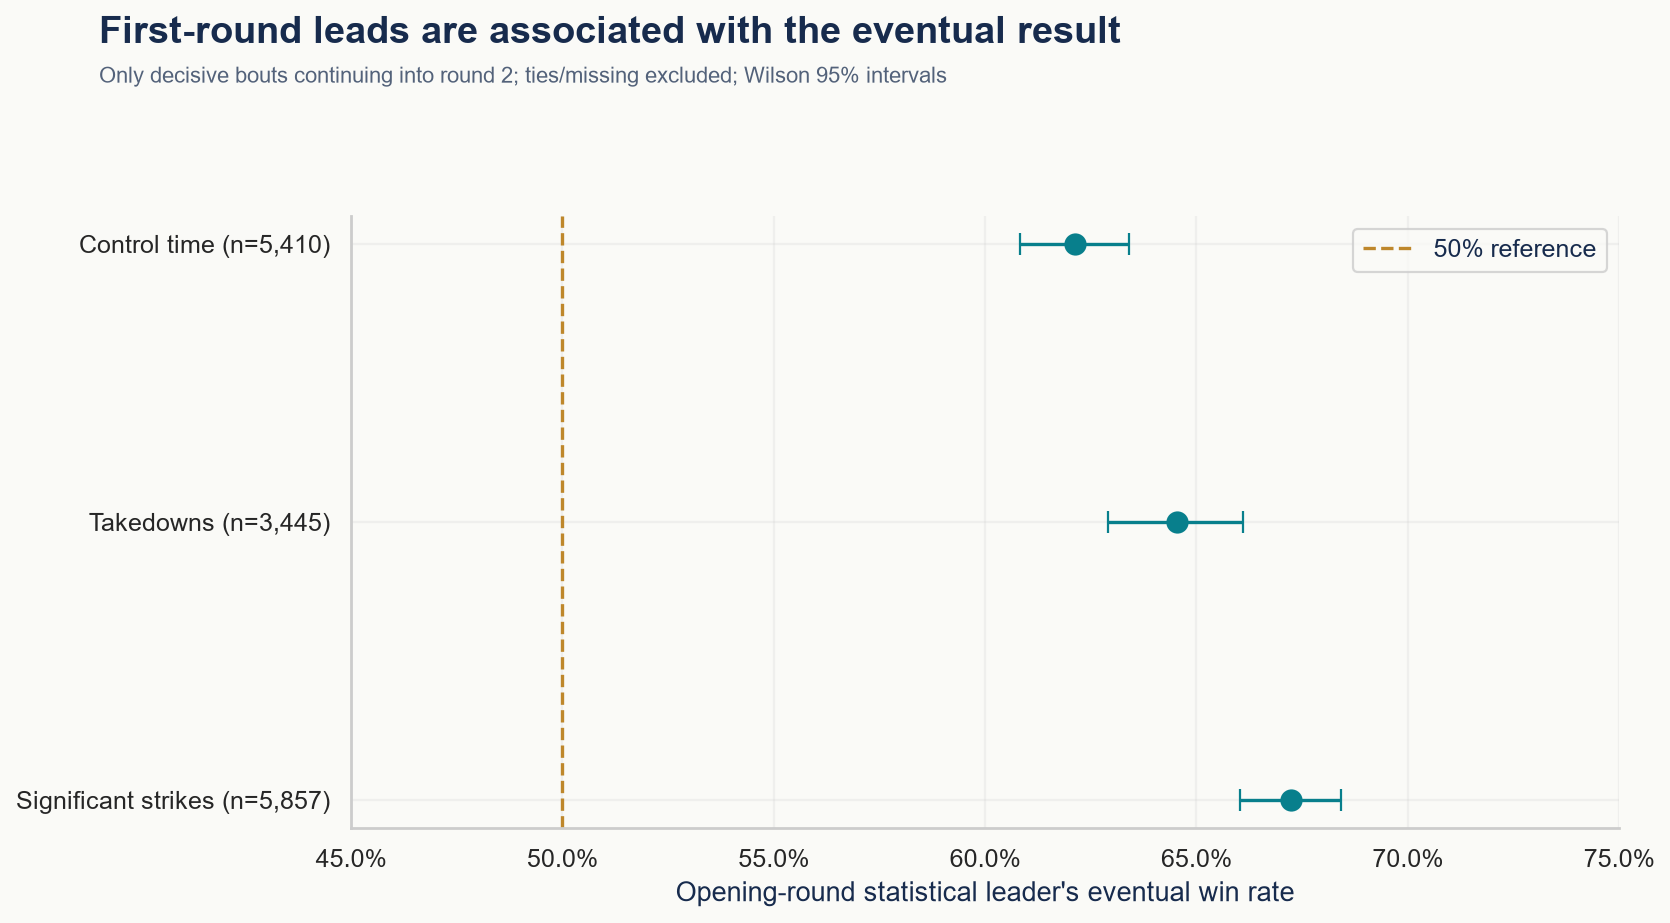

In [9]:
from src.research_visualization import research_chart
show(research_chart('06'))

In [10]:
display(deep_tables['deep_round_exposure'])

,scheduled_rounds,round,reached,finishes,observed_minutes,finish_risk,finishes_per_100_minutes
0,3,1,7777,2088,33905.116667,0.268484,6.158363
1,3,2,5643,1254,25404.233333,0.222222,4.936185
2,3,3,4361,591,20390.366667,0.135519,2.898428
3,5,1,785,175,3512.150000,0.222930,4.982703
4,5,2,607,128,2731.383333,0.210873,4.686270
5,5,3,477,85,2197.433333,0.178197,3.868149
6,5,4,390,50,1848.733333,0.128205,2.704554
7,5,5,339,35,1619.666667,0.103245,2.160938


In [11]:
display(deep_tables['deep_paired_round_pace'])

,fighter_pairs,fights,round1_rate,round2_rate,paired_change,event_bootstrap_low,event_bootstrap_high
0,8722,4361,3.179271,3.48537,0.3061,0.253775,0.358326


In [12]:
display(deep_tables['deep_opening_round_leads'])

,round1_metric,eligible_fights,leader_wins,leader_win_rate,low,high,excluded_ties_or_missing
0,sig_landed,5857,3938,0.672358,0.660228,0.684262,279
1,td_success,3445,2223,0.645283,0.629153,0.661089,2691
2,ctrl_seconds,5410,3361,0.621257,0.608249,0.634092,726


In [13]:
display(deep_tables['deep_control_coverage'])

,fight_year,fighter_rounds,known_control_share
0,1994,58,0.000000
1,1995,74,0.000000
2,1996,78,0.000000
3,1997,96,0.000000
4,1998,60,0.000000
5,1999,158,0.582278
6,2000,182,1.000000
7,2001,184,1.000000
8,2002,232,1.000000
9,2003,176,1.000000


## Research extension: How do bonus era and award category change the interpretation?

The following answers are computed from the current snapshot. Tables expose denominators and missingness so the claims can be checked.

In [14]:
from src.research import run_chapter, display_answers
deep_tables, deep_answers = run_chapter('09')
display_answers(deep_answers)

### Is the finish-bonus association still present within recent years?

**Answer.** In 2020-2025, 50.9% of 1,485 finishes and 8.5% of 1,484 decisions have at least one recorded bonus category.

**Interpretation.** Comparisons start in 2006, the first observed bonus year, and exclude partial 2026. Recorded absence is treated as no bonus; source completeness is not independently verified. Eras reflect observed category coverage, not a causal policy experiment.

### Do Fight of the Night and performance awards tell the same story?

**Answer.** Across 2015-2025, Fight of the Night decorates 5.0% of finishes and 7.8% of decisions. The category table separates this from performance awards.

**Interpretation.** 2014 is omitted as a transition year in the source categories. A fight can have multiple categories. Records identify decorated fights, not recipient identities or award money.

### Can division composition alone explain the modern finish-bonus gap?

**Answer.** Across 11 shared divisions with at least 50 finishes and 50 decisions each, pooled division weights give 48.1% for finishes versus 8.4% for decisions: a 39.71-point gap.

**Interpretation.** Both outcomes use the same pooled division weights in 2015-2025. This removes that composition difference only; opponent quality, card prominence and discretionary selection remain unmeasured.

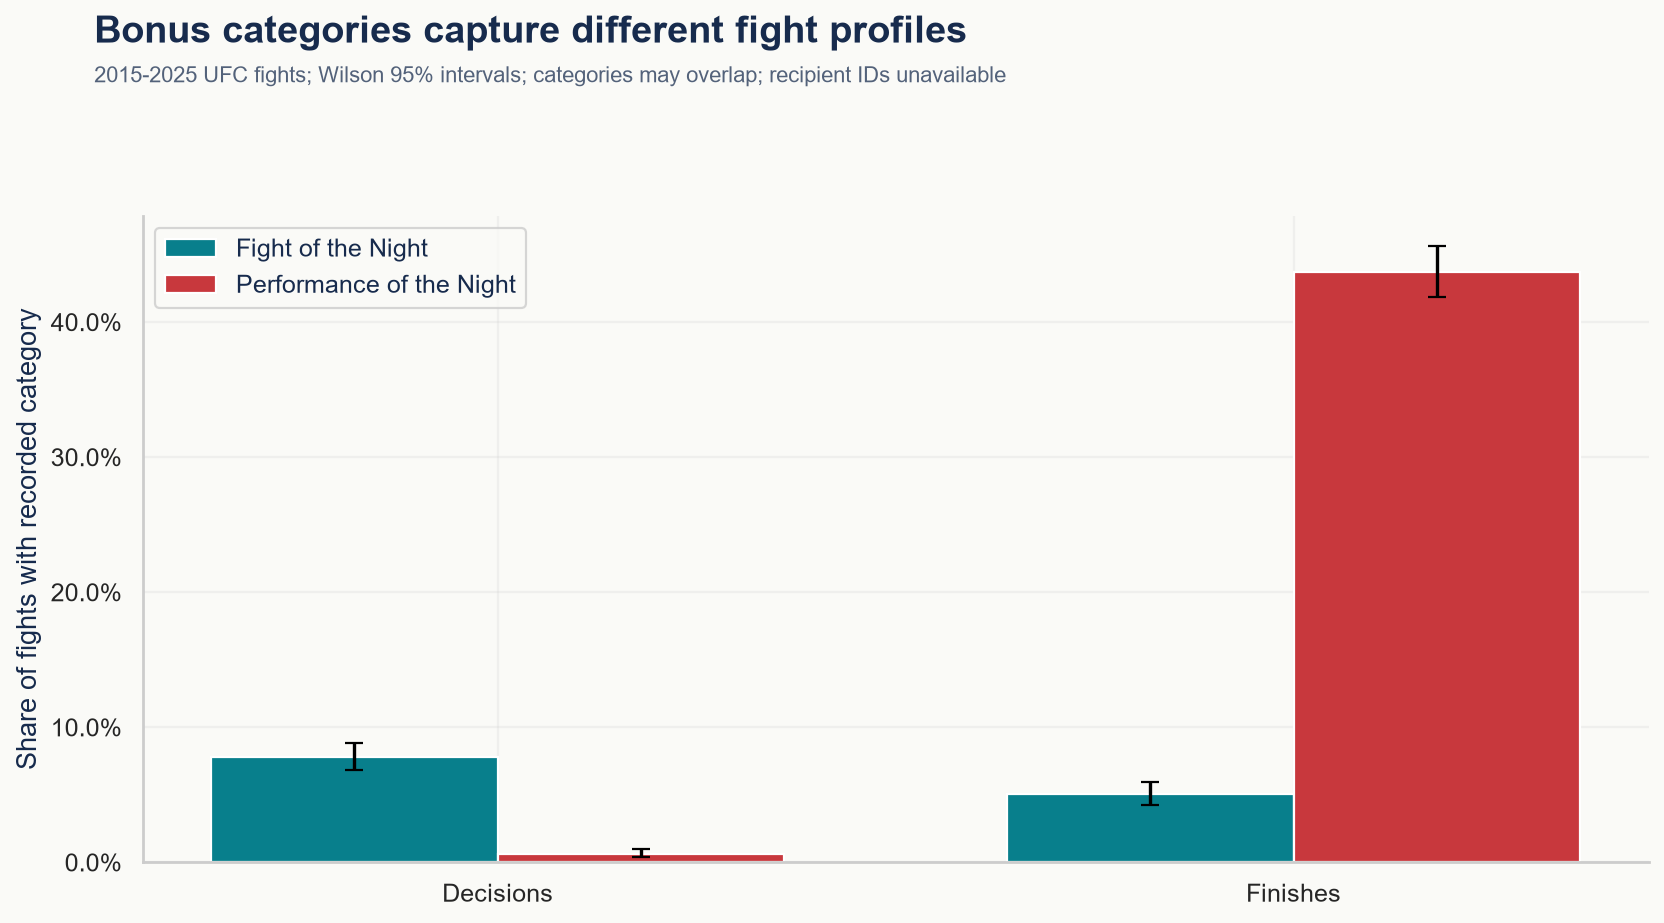

In [15]:
from src.research_visualization import research_chart
show(research_chart('09'))

In [16]:
display(deep_tables['deep_bonus_eras'])

,era,outcome,n,successes,rate,low,high
0,2006-2013,Decision,868,104,0.119816,0.099870,0.143112
1,2006-2013,Finish,1121,422,0.376450,0.348555,0.405188
2,2006-2013,Other,36,8,0.222222,0.117163,0.380847
3,2014-2019,Decision,1424,120,0.084270,0.070936,0.099840
4,2014-2019,Finish,1432,634,0.442737,0.417198,0.468583
5,2014-2019,Other,60,5,0.083333,0.036120,0.180689
6,2020-2025,Decision,1484,126,0.084906,0.071773,0.100181
7,2020-2025,Finish,1485,756,0.509091,0.483674,0.534461
8,2020-2025,Other,64,7,0.109375,0.054001,0.208986


In [17]:
display(deep_tables['deep_bonus_categories'])

,outcome,n,successes,rate,low,high,category
0,Decision,2662,207,0.077761,0.068186,0.088553,Fight of the Night
1,Finish,2670,134,0.050187,0.042533,0.059134,Fight of the Night
2,Other,114,5,0.043860,0.018878,0.098581,Fight of the Night
3,Decision,2662,16,0.006011,0.003703,0.009742,Performance of the Night
4,Finish,2670,1167,0.437079,0.418368,0.455970,Performance of the Night
5,Other,114,7,0.061404,0.030059,0.121343,Performance of the Night


In [18]:
display(deep_tables['deep_bonus_division_standardization'])

,weight_class,outcome,n,successes,rate,low,high,pooled_weight
0,Bantamweight,Decision,308,26,0.084416,0.058257,0.120813,0.107866
1,Bantamweight,Finish,257,131,0.509728,0.448918,0.570251,0.107866
4,Featherweight,Decision,327,36,0.110092,0.080589,0.148649,0.117029
5,Featherweight,Finish,286,148,0.517483,0.459723,0.574778,0.117029
6,Flyweight,Decision,175,12,0.068571,0.039658,0.116019,0.062237
7,Flyweight,Finish,151,77,0.509934,0.430948,0.588427,0.062237
8,Heavyweight,Decision,150,2,0.013333,0.003664,0.047307,0.074647
9,Heavyweight,Finish,241,118,0.489627,0.427174,0.552405,0.074647
10,Light Heavyweight,Decision,141,10,0.070922,0.038977,0.125627,0.074647
11,Light Heavyweight,Finish,250,121,0.484000,0.422764,0.545720,0.074647
